#Medical Insurance Charges Prediciton

## Table of Contents

*   [Data Loading and Initial Inspection](#Data-Loading-and-Initial-Inspection)
*   [Summary Statistics](#Summary-Statistics)
*   [Check for Missing Values](#Check-for-Missing-Values)
*   [Exploratory Data Analysis](#Exploratory-Data-Analysis)
    *   [Categorical Feature Distributions](#Categorical-Feature-Distributions)
    *   [Numerical Feature Distributions](#Numerical-Feature-Distributions)
    *   [Feature Correlation](#Feature-Correlation)
    *   [Impact of Categorical Features on Charges](#Impact-of-Categorical-Features-on-Charges)
    *   [Impact of Numerical Features on Charges](#Impact-of-Numerical-Features-on-Charges)
*   [Model Building and Evaluation](#Model-Building-and-Evaluation)
    *   [Baseline Model](#Baseline-Model)
    *   [Linear Regression Model](#Linear-Regression-Model)
    *   [Random Forest Regressor Model](#Random-Forest-Regressor-Model)
    *   [Random Forest with Log Transformation](#Random-Forest-with-Log-Transformation)
    *   [XgBoost Model](#XgBoost-Model)
*   [Model Comparison](#Model-Comparison)
*   [Conclusion](#Conclusion)

#Load CSV, check shape and dtypes  



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

import kagglehub

path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Dataset downloaded to: /kaggle/input/insurance


## Data Loading and Initial Inspection

In [2]:
df = pd.read_csv(f"{path}/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.tail(5)

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


#Summary Statistics

In [4]:
df.info()
print(df.shape)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
(1338, 7)


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Check for Missing Values

In [5]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


#Exploratory Data Analysis

In [6]:
sns.set_style('whitegrid')
palette = ['#4C72B0', '#DD8452']
model_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#E377C2']
metric_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']


### Categorical Feature Distributions

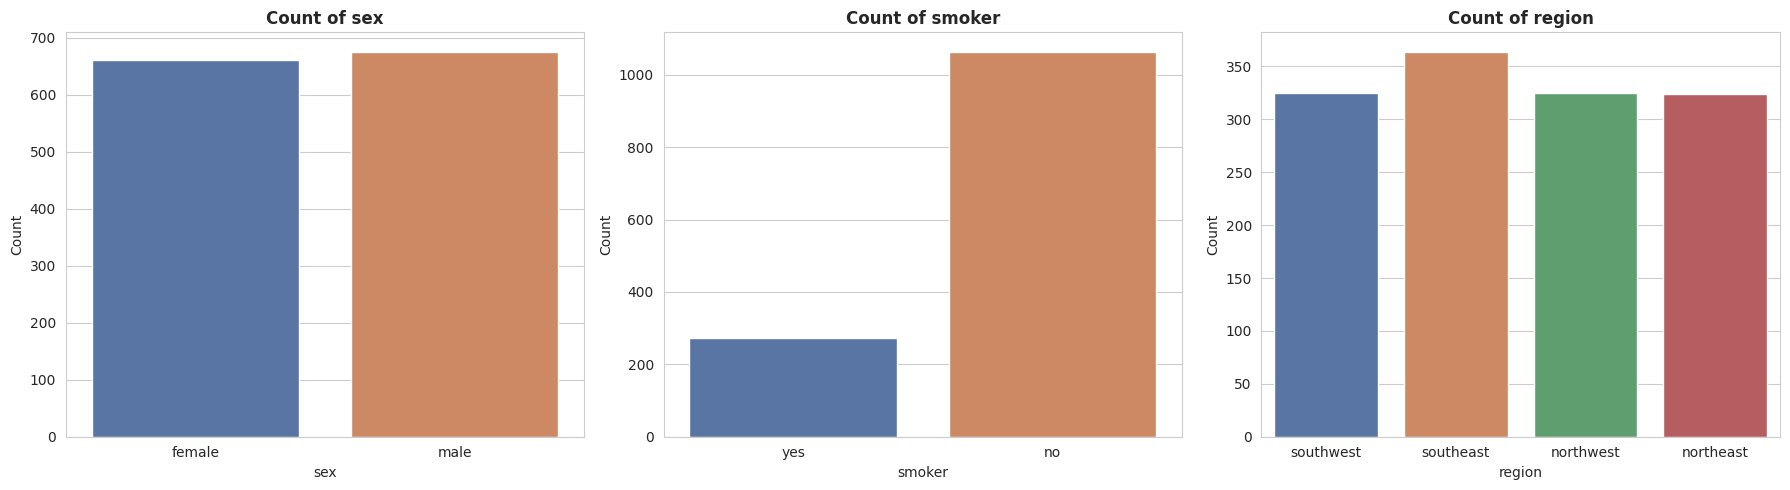

In [7]:
categorical_columns = ['sex', 'smoker', 'region']
numerical_columns = ['age', 'bmi', 'children']

fig_cat, axes_cat = plt.subplots(1, len(categorical_columns), figsize=(18, 5))
axes_cat = axes_cat.ravel()
for i, col in enumerate(categorical_columns):
  n_categories = df[col].nunique()
  sns.countplot(data=df, x=col, ax=axes_cat[i], hue=col, legend=False, palette=model_palette[:n_categories])
  axes_cat[i].set_title(f'Count of {col}', fontweight='bold')
  axes_cat[i].set_xlabel(col)
  axes_cat[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Numerical Feature Distributions

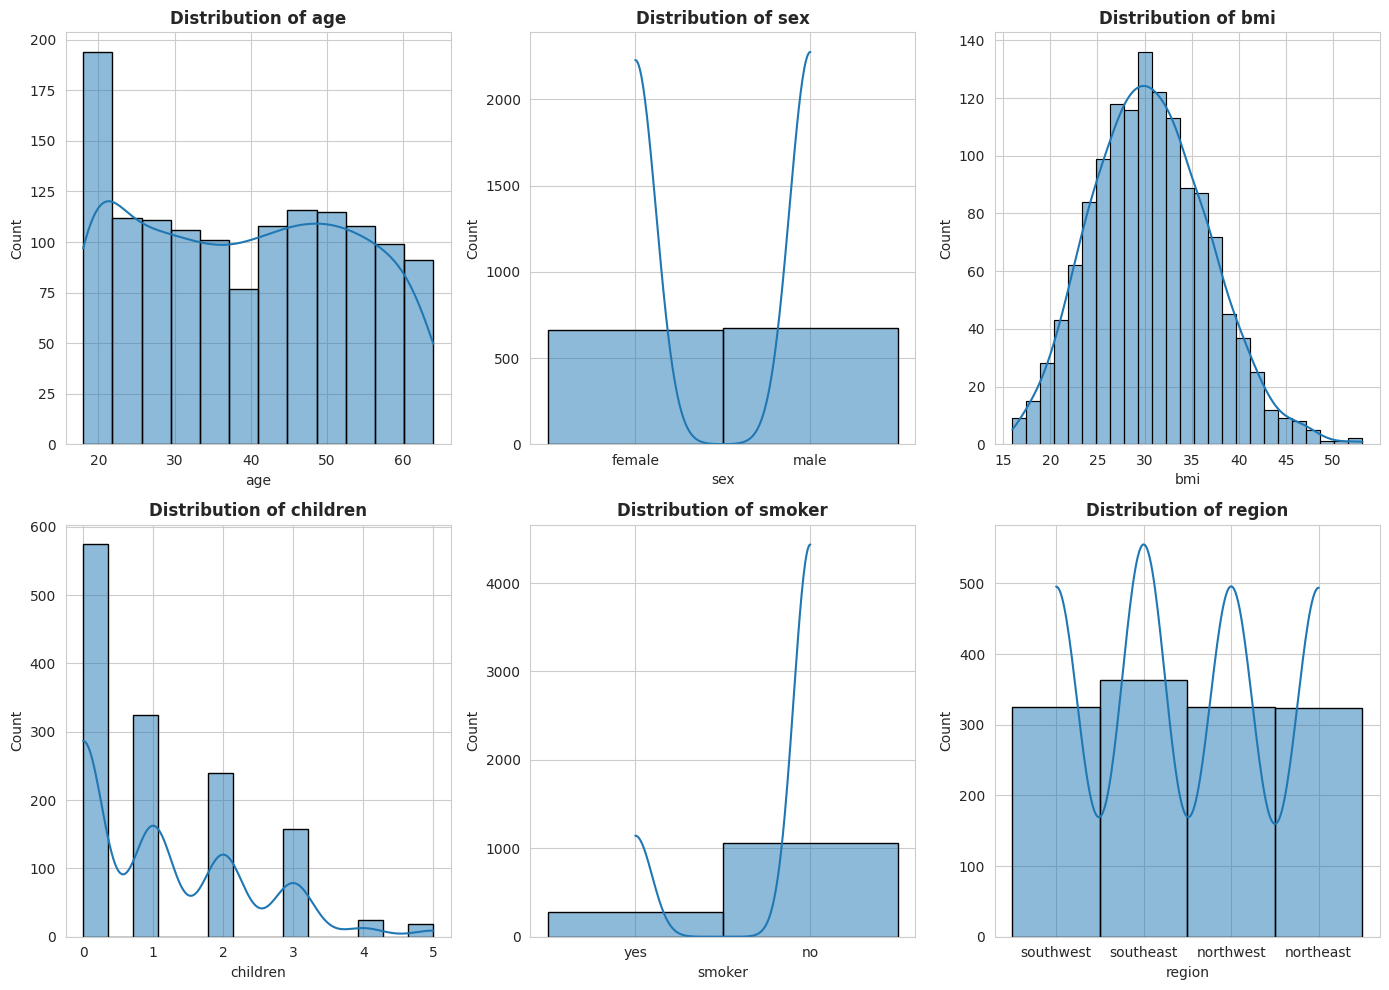

In [8]:
cols = df.columns[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.ravel()
for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Correlation

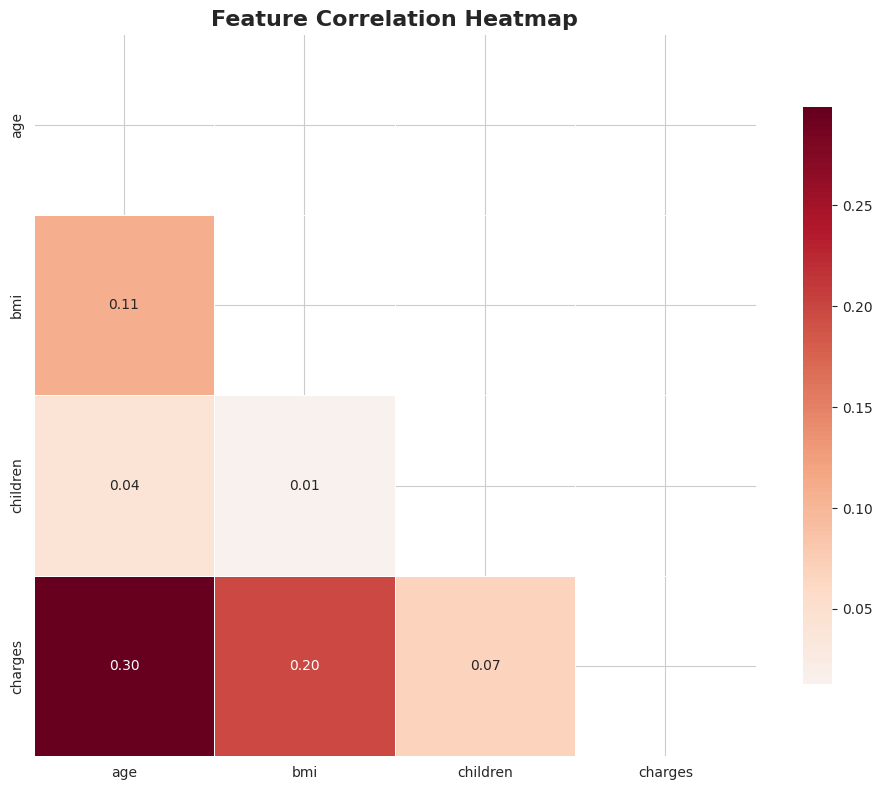

In [9]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=np.number)
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Impact of Categorical Features on Charges

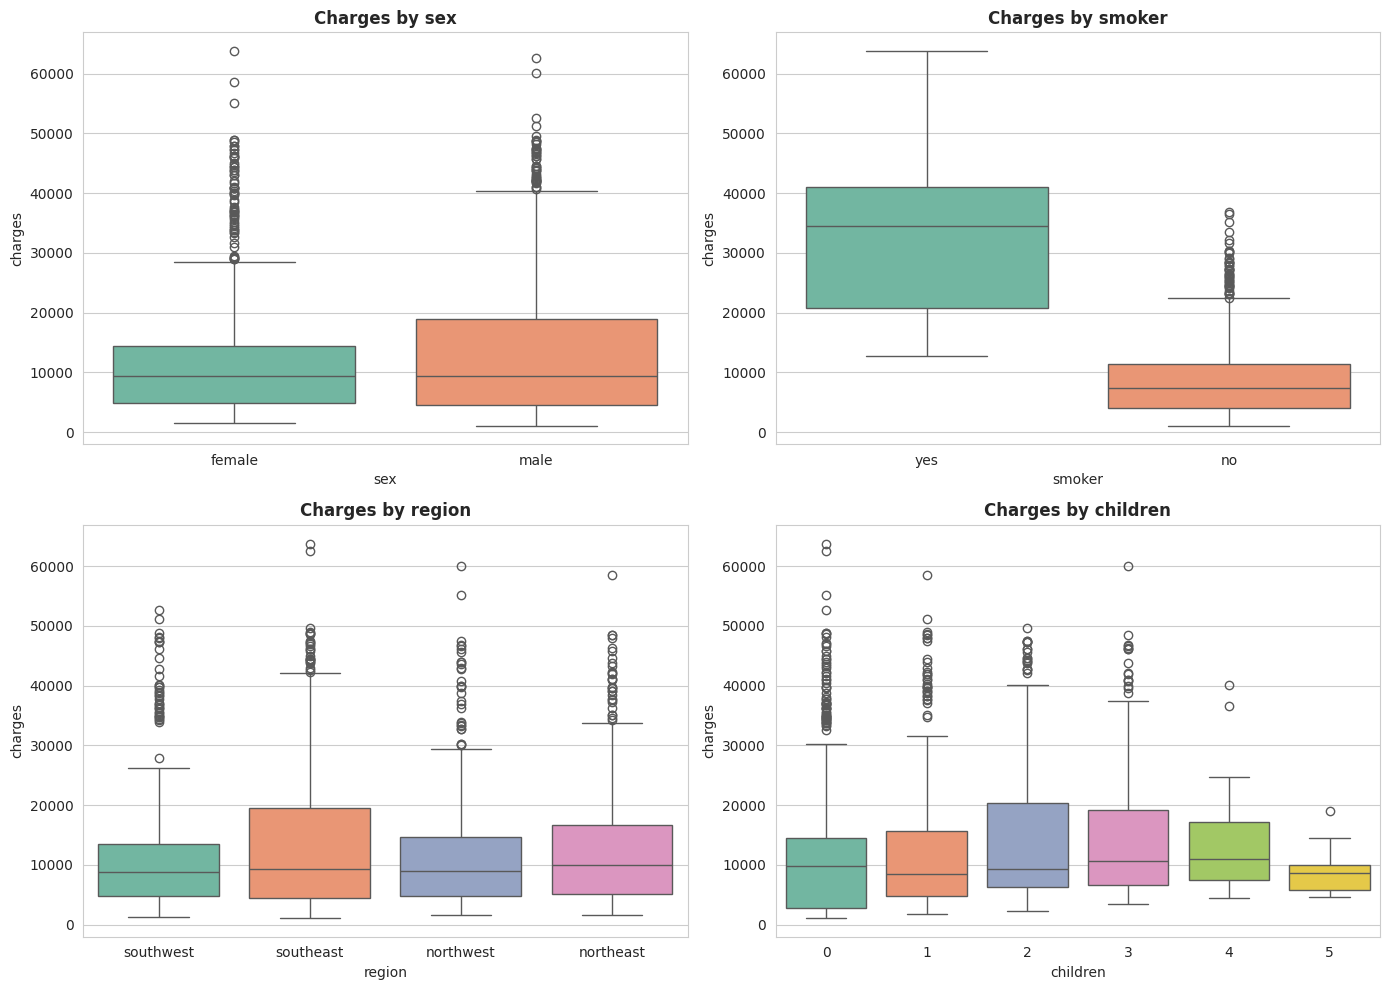

In [10]:
cat_cols = ['sex', 'smoker', 'region', 'children']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(cat_cols):
    sns.boxplot(data=df, x=col, y='charges', ax=axes[i//2, i%2], hue=col, legend=False, palette='Set2')
    axes[i//2, i%2].set_title(f'Charges by {col}', fontweight='bold')
plt.tight_layout()
plt.show()

### Impact of Numerical Features on Charges

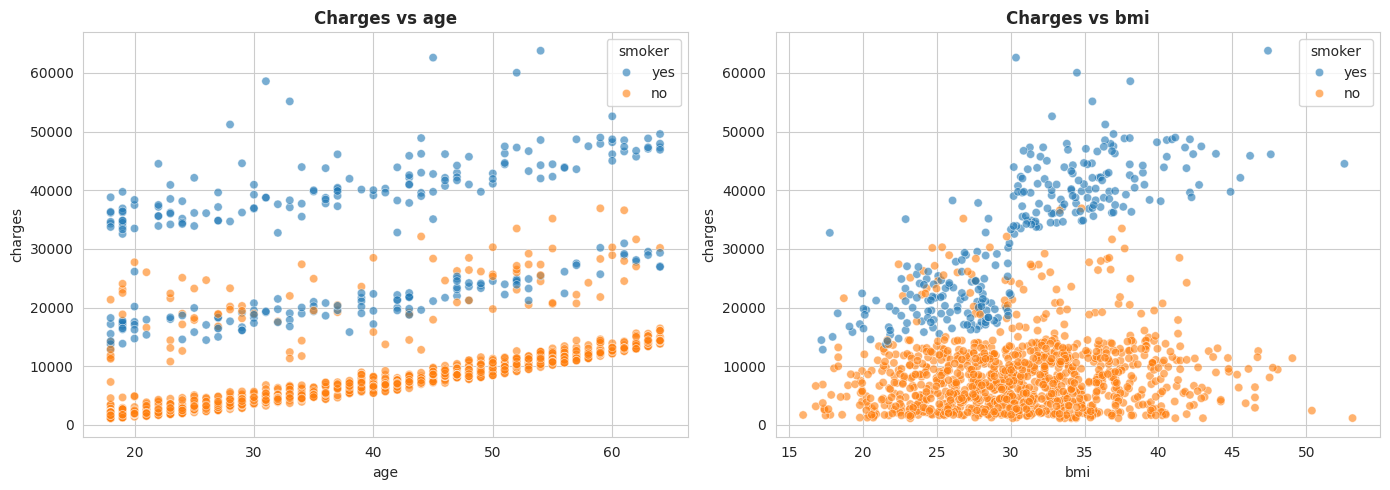

In [11]:
num_cols = ['age', 'bmi']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(num_cols):
    sns.scatterplot(data=df, x=col, y='charges', hue='smoker', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Charges vs {col}', fontweight='bold')
plt.tight_layout()
plt.show()

# Model Building and Evaluation

### Baseline Model

In [12]:
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred = [y_train.mean()] * len(y_test)
print("Baseline MAE:", mean_absolute_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:   {mae:,.2f}")
print(f"RMSE:  {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)



Baseline MAE: 9593.33846086229
MAE:   9,593.34
RMSE:  12,465.61
R²:   -0.0009
Feature shape: (1338, 6)
Target shape: (1338,)
Train set shape: (1070, 6)
Test set shape: (268, 6)


### Linear Regression Model

In [13]:
cat_cols = ['sex', 'smoker', 'region']
num_cols = ['age', 'bmi', 'children']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_cols)
], remainder='passthrough')

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2   = r2_score(y_test, y_pred_lr)

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  $4,181.19
RMSE: $5,796.28
R²:   0.7836


In [14]:
model = LinearRegression()

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

pipeline.fit(X_train, y_train)

print(pipeline.score(X_test, y_test))

0.7835929767120722


### Random Forest Regressor Model

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE:  ${mae_rf:,.2f}")
print(f"RMSE: ${rmse_rf:,.2f}")
print(f"R²:   {r2_rf:.4f}")

MAE:  $2,563.57
RMSE: $4,594.50
R²:   0.8640


### Random Forest with Log Transformation

In [16]:
y_train_log = np.log(y_train)
rf_pipeline.fit(X_train, y_train_log)
y_pred_log = np.exp(rf_pipeline.predict(X_test))

mae_log = mean_absolute_error(y_test, y_pred_log)
print(f"Log-transform MAE: ${mae_log:,.2f}")

Log-transform MAE: $2,079.99


### XgBoost Model

In [17]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE:  ${mean_absolute_error(y_test, y_pred_xgb):,.2f}")
print(f"XGBoost RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_xgb)):,.2f}")
print(f"XGBoost R²:   {r2_score(y_test, y_pred_xgb):.4f}")

XGBoost MAE:  $2,446.47
XGBoost RMSE: $4,347.48
XGBoost R²:   0.8783


## Model Comparison

In [18]:

y_pred_baseline = [y_train.mean()] * len(y_test)
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)


mae_lr = mae
rmse_lr = rmse
r2_lr = r2


mae_rf = mae_rf
rmse_rf = rmse_rf
r2_rf = r2_rf


rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log = r2_score(y_test, y_pred_log)


mae_xgb = mae_xgb
rmse_xgb = rmse_xgb
r2_xgb = r2_xgb

comparison_df = pd.DataFrame({
    'Model': ['Baseline', 'Linear Regression', 'Random Forest', 'Random Forest (Log-Transform)', 'XGBoost'],
    'MAE': [mae_baseline, mae_lr, mae_rf, mae_log, mae_xgb],
    'RMSE': [rmse_baseline, rmse_lr, rmse_rf, rmse_log, rmse_xgb],
    'R2 Score': [r2_baseline, r2_lr, r2_rf, r2_log, r2_xgb]
})


comparison_df['MAE'] = comparison_df['MAE'].map('${:,.2f}'.format)
comparison_df['RMSE'] = comparison_df['RMSE'].map('${:,.2f}'.format)
comparison_df['R2 Score'] = comparison_df['R2 Score'].map('{:.4f}'.format)

display(comparison_df.set_index('Model'))


,MAE,RMSE,R2 Score
Model,,,
Baseline,"$9,593.34","$12,465.61",-0.0009
Linear Regression,"$4,181.19","$5,796.28",0.7836
Random Forest,"$2,563.57","$4,594.50",0.8640
Random Forest (Log-Transform),"$2,079.99","$4,375.56",0.8767
XGBoost,"$2,446.47","$4,347.48",0.8783


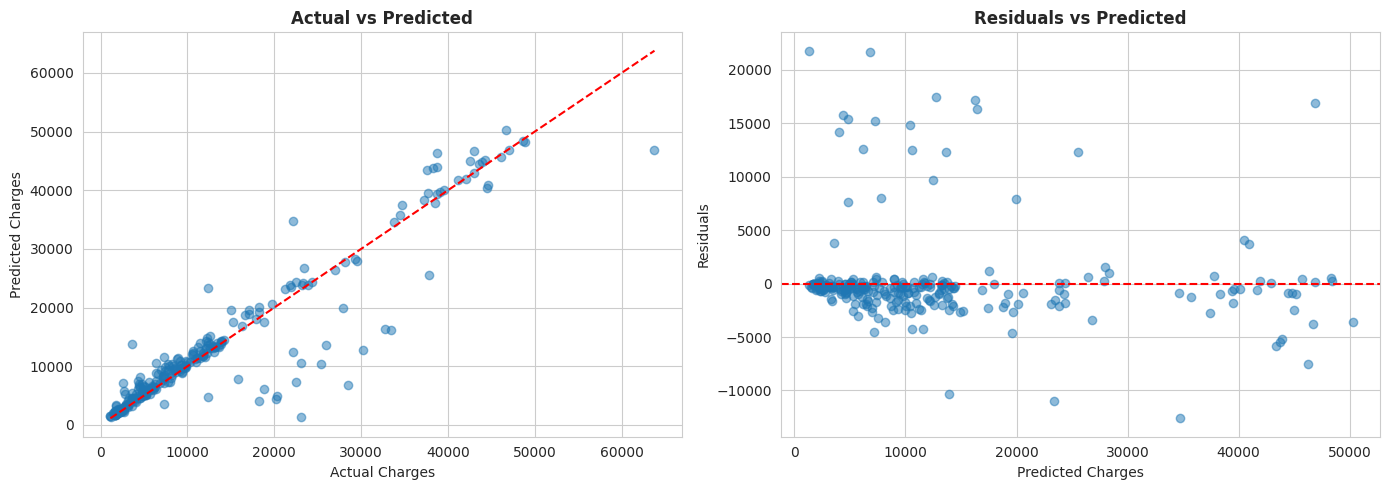

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_log, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Actual vs Predicted', fontweight='bold')

residuals = y_test - y_pred_log
axes[1].scatter(y_pred_log, residuals, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusion

*   **Random Forest models performed better than Linear Regression**, capturing more complex relationships in the data.
*   **Log-transforming the 'charges' variable significantly improved the Random Forest model's accuracy**, reducing prediction errors (MAE and RMSE) and increasing R².
*   The improved performance with log-transformation suggests that `charges` data is right-skewed, and modeling it in log-space helps the model focus on proportional errors, which is often beneficial for financial data.
*   Although the best model still shows some large errors (RMSE > MAE), indicating challenges with high-cost predictions, the log-transformed Random Forest model provides the most accurate results in this analysis.